Time:  2024-06-27T20:31:46.345437
Reading from PhoXi


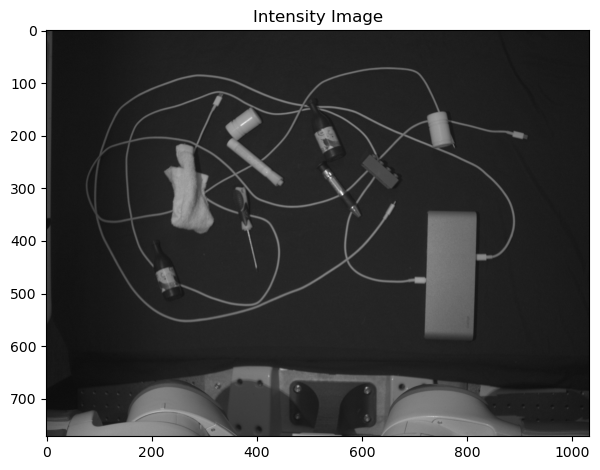

True

In [4]:
import matplotlib.pyplot as plt

from phoxipy import PhoXiSensor
import datetime

time = datetime.datetime.now().isoformat()
print("Time: ", time)

p = PhoXiSensor("1703005")
p.start()

frame = p.read()
plt.title("Intensity Image")
plt.imshow(frame.color.data)
plt.tight_layout()
plt.show()
plt.imsave(f"intensity_image{time}.png", frame.color.data)
p.stop()


In [5]:
import PIL.Image as Image
import numpy as np
from decluttering.data.utils.detic_dataloader import DeticDataloader
import matplotlib.pyplot as plt

detic = DeticDataloader()
detic.create()
detic.default_vocab()

Resetting zs_weight datasets/metadata/lvis_v1_clip_a+cname.npy


In [6]:

# im_frame1 = Image.open('/home/justinyu/multicable-decluttering/decluttering/scripts/test/intensity_image.png')
# im_frame1 = im_frame1.resize((640, 480))
im_frame1 = frame.color.data
np_frame1 = np.array(im_frame1)

# remove alpha channel
np_frame1 = np_frame1[0:650, :, :3]


/home/justinyu/multicable-decluttering/decluttering/data/detectron2_repo/detectron2/structures/image_list.py:99: UserWarning: __floordiv__ is deprecated, and its behavior will change in a future version of pytorch. It currently rounds toward 0 (like the 'trunc' function NOT 'floor'). This results in incorrect rounding for negative values. To keep the current behavior, use torch.div(a, b, rounding_mode='trunc'), or for actual floor division, use torch.div(a, b, rounding_mode='floor').
  max_size = (max_size + (stride - 1)) // stride * stride


Inference time:  1.3846337795257568


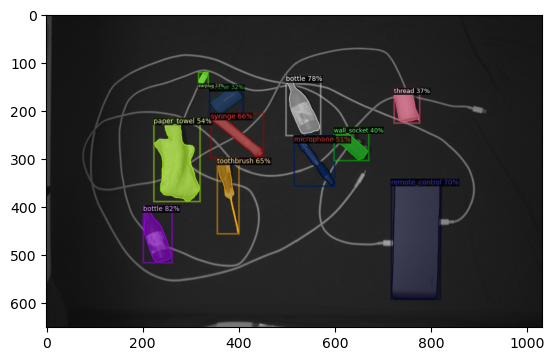

In [7]:

out = detic.predict(np_frame1)
output_im = out['vis'].get_image()
# print(output_im.shape)
plt.imshow(output_im)
plt.imsave(f"output_image{time}.png", output_im)


Number of masks before filtering torch.Size([13, 1, 650, 1032])
Area of masks before filtering tensor([ 3824,  3979, 23561,  2536,  1908,  2338,  9698,  1986,  1968,  2072,
         2606,  2339,   261], device='cuda:0')
torch.Size([11, 1, 650, 1032])
Number of masks after filtering:  11
Area of masks after filtering tensor([3824, 3979, 2536, 1908, 2338, 9698, 1986, 1968, 2072, 2606, 2339],
       device='cuda:0')


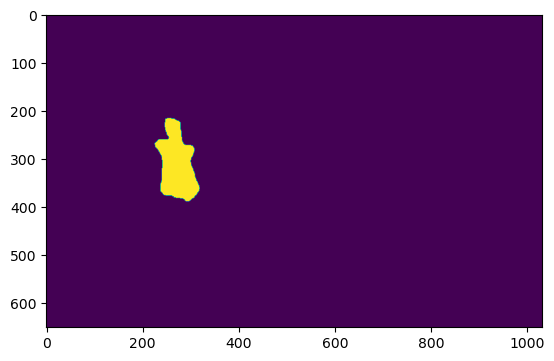

torch.Size([1, 650, 1032])
tensor(9698, device='cuda:0')


In [8]:
import torch
num_masks = out['masks'].shape[0]
print("Number of masks before filtering", out['masks'].shape)
print("Area of masks before filtering", torch.sum(out['masks'], dim = (1,2,3)))

def filter_mask_by_area(masks, max_area = 10000, min_area = 500):
    """
    Filter masks by area
    """
    mask_areas = torch.sum(masks, dim = (1,2,3))
    mask_areas = mask_areas.cpu().numpy()
    mask_areas = mask_areas.reshape(-1)
    masks_filtered = masks[(mask_areas < max_area) & (min_area < mask_areas)]
    return masks_filtered

def get_largest_mask(masks):
    sorted, indices = torch.sort(torch.sum(masks, dim = (1,2,3)), descending=True)
    return masks[indices[0]]

filtered_areas = filter_mask_by_area(out['masks'])
print(filtered_areas.shape)
num_masks = filtered_areas.shape[0]
print("Number of masks after filtering: ", num_masks)
print("Area of masks after filtering", torch.sum(filtered_areas, dim = (1,2,3)))
# for i in num_masks:
#     plt.imshow(out['masks'][i])
#     plt.show()

plt.imshow(get_largest_mask(filtered_areas).permute((1,2,0)).squeeze(-1).cpu().numpy())
plt.show()

# sorted, indices = torch.sort(torch.sum(filtered_areas, dim = (1,2,3)), descending=True)
# print(indices)

# print(sorted)

# print(torch.sum(filtered_areas, dim = (1,2,3))[indices[0]])
print(get_largest_mask(filtered_areas).shape)
print(torch.sum(get_largest_mask(filtered_areas)))

The oriented bounding box is: ((270.9461364746094, 302.4396667480469), (176.22361755371094, 81.24662017822266), 82.94769287109375)


/tmp/ipykernel_175452/458821785.py:42: DeprecationWarning: `np.int0` is a deprecated alias for `np.intp`.  (Deprecated NumPy 1.24)
  box = np.int0(box)


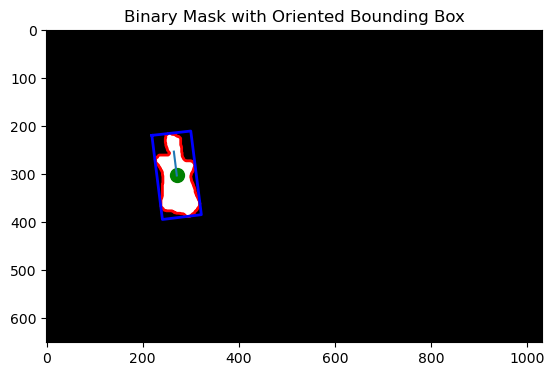

[270.94613647 302.43966675]
-0.12277541926144711
-0.9924344796636076


In [16]:
import cv2
import numpy as np

def get_oriented_bounding_box(binary_mask):
    """
    Fit the tightest oriented bounding box around a 2D binary mask.
    
    Parameters:
    binary_mask (numpy.ndarray): A 2D numpy array representing the binary mask image.
    
    Returns:
    tuple: The (center (x, y), (width, height), angle of rotation) of the bounding box.
    """
    # Ensure the input is a binary mask
    binary_mask = np.asarray(binary_mask, dtype=np.uint8)
    
    # Find contours in the binary mask
    contours, _ = cv2.findContours(binary_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    # Get the largest contour, assuming the mask is connected
    largest_contour = max(contours, key=cv2.contourArea)
    
    # Get the minimum area bounding rectangle
    rect = cv2.minAreaRect(largest_contour)
    
    return rect, largest_contour


rect, contour = get_oriented_bounding_box(get_largest_mask(filtered_areas).permute((1,2,0)).squeeze(-1).cpu().numpy())
print(f"The oriented bounding box is: {rect}")

def plot_mask_with_bbox(binary_mask, rect, contour):
    """
    Plot the binary mask with the oriented bounding box.
    
    Parameters:
    binary_mask (numpy.ndarray): A 2D numpy array representing the binary mask image.
    rect (tuple): The (center (x, y), (width, height), angle of rotation) of the bounding box.
    contour (numpy.ndarray): Contour of the largest component in the binary mask.
    """
    box = cv2.boxPoints(rect)
    box = np.int0(box)

    angle = rect[2]
    if rect[1][0] > rect[1][1]:
        angle = angle + 90
    
    plt.figure()
    plt.imshow(binary_mask, cmap='gray')
    plt.plot(contour[:, 0, 0], contour[:, 0, 1], 'r', linewidth=2)
    plt.plot(*zip(*np.vstack([box, box[0]])), 'b-', linewidth=2)
    plt.scatter(rect[0][0], rect[0][1], color='green', s=100)
    plt.plot([rect[0][0], rect[0][0]-50*np.sin(np.radians(angle))], [rect[0][1], rect[0][1]+50*np.cos(np.radians(angle))])
    plt.title("Binary Mask with Oriented Bounding Box")
    plt.show()

plot_mask_with_bbox(get_largest_mask(filtered_areas).permute((1,2,0)).squeeze(-1).cpu().numpy(), rect, contour)

center = np.array(rect[0])
print(center)
angle = rect[2]
if rect[1][0] > rect[1][1]:
    angle = angle + 90
    
print(-np.sin(np.radians(angle)))
print(np.cos(np.radians(angle)))


In [42]:
def get_two_objects(masks):
    rect_centers = []
    rect_angles = []
    for i in range(masks.shape[0]):
        rect, contour = get_oriented_bounding_box(masks[i])
        angle = rect[2]
        if rect[1][0] > rect[1][1]:
            angle = angle + 90
        rect_centers.append(rect[0])
        rect_angles.append(angle)
    
    # print(np.asarray(rect_centers)[:, 1])
    # print(np.argsort(np.asarray(rect_centers)[:, 1]))
    # x_sorted = np.argsort(np.asarray(rect_centers)[:, 1])

    rh = (np.asarray(rect_centers)[:, 0] > 550)
    # print(rh)
    # if len(rect_centers) > 1:
    #     idx = np.argsort(np.asarray(rect_centers)[:, 1])
    #     rect_centers = np.asarray(rect_centers)[idx]
    #     rect_angles = np.asarray(rect_angles)[idx]
    # print(rect_angles)

    for i in range(masks.shape[0]):
        # Iterate through right hand and left hand objects and until one is found with distance > 100
        if rh[i]:
            for j in range(masks.shape[0]):
                if not rh[j]:
                    if rect_centers[i][0] - rect_centers[j][0] > 100:
                        # print("Two objects found")
                        # print(rect_centers[i])
                        # print(rect_centers[j])
                        # print(rect_centers[i][0] - rect_centers[j][0])
                        return True, (rect_centers[i], rect_angles[i]), (rect_centers[j], rect_angles[j])
    return False, rect_centers, rect_angles


# print(filtered_areas.shape)
if filtered_areas.shape[0] > 1:
    found, o, t= get_two_objects(filtered_areas.squeeze(1).cpu().numpy())
    if found:
        print("Two objects found")
        print(o)
        print(t)
        centers = [o[0], t[0]]
        angles = [o[1], t[1]]
    else:
        print("Only one object found")
        print(o[0])
        centers = o[0]
        angles = t[0]
else:
    print("Only one object found")
    # print(filtered_areas.shape)
    # print(filtered_areas.squeeze(1).shape)
    rect, contour = get_oriented_bounding_box(get_largest_mask(filtered_areas).permute((1,2,0)).squeeze(-1).cpu().numpy())
    centers = rect[0]
    angles = rect[2]
    if rect[1][0] > rect[1][1]:
        angles = angles + 90

print(centers)
print(angles)


Two objects found
((559.623291015625, 303.906005859375), 142.66680908203125)
((225.35733032226562, 456.08782958984375), 160.90650939941406)
[(559.623291015625, 303.906005859375), (225.35733032226562, 456.08782958984375)]
[142.66680908203125, 160.90650939941406]


In [43]:
from decluttering.deprecated.push_through_backup2 import get_poi_and_vec_for_push, perform_push_through, perform_pindown, perform_pick_away, perform_point_grasp, drop_in_bin, perform_bimanual_point_grasp
from decluttering.deprecated.demopipeline import DemoPipeline

def initialize_pipeline(logLevel):
    pipeline = DemoPipeline(viz=False, loglevel=logLevel, initialize_iface=True)
    pipeline.iface.open_grippers()
    pipeline.iface.sync()
    pipeline.iface.home()
    pipeline.iface.sync()
    return pipeline

pipeline = initialize_pipeline('DEBUG')
pipeline.iface.home()
pipeline.iface.sync()
pipeline.iface.open_grippers()
pipeline.iface.sync()

# print("Angle is: ", angle)


if len(centers) == 2:
    print("performing bimanual")
    perform_bimanual_point_grasp(centers, np.radians(angles), pipeline)
else:
    print("performing single arm")
    perform_point_grasp(centers, np.radians(angles), pipeline)

pipeline.iface.home()
pipeline.iface.sync()

Directory 'logs_2024-06-27_21-07-16' created
./logs/full_rollouts/logs_2024-06-27_21-07-16


/home/mallika/anaconda3/envs/lipnew/lib/python3.8/site-packages/torch/nn/modules/lazy.py:178: UserWarning: Lazy modules are a new feature under heavy development so changes to the API or functionality can happen at any moment.
  warnings.warn('Lazy modules are a new feature under heavy development '


move joints
move joints
performing bimanual
Using right arm
[0.4480719042104867, -0.00027061686823921793, 0.06]
Using left arm
[0.30474944147236677, 0.2960742595333599, 0.06]
move joints
move joints


RuntimeError: Timeout during sync